In [7]:
import os  # 这个cell不能删, 否则会有报错
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

## 2.2 实现一个简单的线性回归模型

### 2.2.1 数据集构建

In [2]:
# 真实函数的参数缺省值为 w = 1.2, b = 0.5
def linear_func(x, w=1.2, b=0.5):
    y = w*x + b
    return y

In [3]:
import paddle

def create_toy_data(func, interval, sample_num, noise=0.0, add_outlier=False, outlier_ratio=0.01):
    """
    根据给定的函数，生成样本
    输入:
        - func: 函数
        - interval: x的取值范围
        - sample_num: 样本数目
        - noise: 噪声均方差
        - add_outlier: 是否生成异常值
        - outlier_ratio: 异常值占比
    输出:
        - X: 特征数据，shape=[n_samples, 1]
        - y: 标签数据，shape=[n_samples, 1]
    """

    # 均匀采样
    # 使用paddle.rand再生成sample_num个随机数
    X = paddle.rand(shape=[sample_num]) * (interval[1] - interval[0]) + interval[0]
    y = func(X)

    # 生成高斯分布的标签噪声
    # 使用paddle.normal生成theta均值，noise标准差的数据
    epsilon = paddle.normal(0, noise, paddle.to_tensor(y.shape[0]))
    y = y + epsilon
    if add_outlier:  # 生成额外的异常点
        outlier_num = int(len(y) * outlier_ratio)
        if outlier_num != 0:
            # 使用paddle.randint生成服从均匀分布的、范围在[0, len(y)) 的随机Tensor
            outlier_idx = paddle.randint(len(y), shape=[outlier_num])
            y[outlier_idx] = y[outlier_idx] * 5
    return X, y

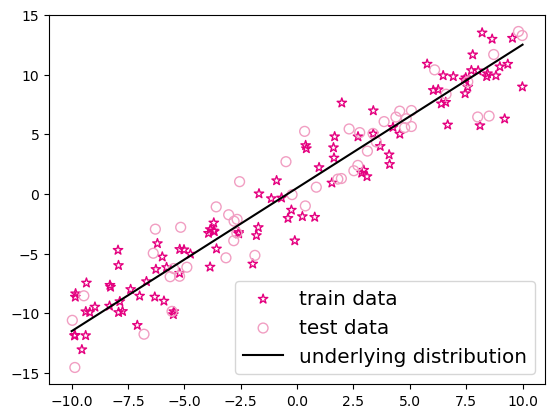

In [4]:
from matplotlib import pyplot as plt  # matplotlib 是 Python 的绘图库
import numpy  # 如果不加numpy库，会报错

func = linear_func
interval = (-10, 10)
train_num = 100  # 训练样本数目
test_num = 50  # 测试样本数目
noise = 2
X_train, y_train = create_toy_data(func=func, interval=interval, sample_num=train_num, noise=noise, add_outlier=False)
X_test, y_test = create_toy_data(func=func, interval=interval, sample_num=test_num, noise=noise, add_outlier=False)

X_train_large, y_train_large = create_toy_data(func=func, interval=interval, sample_num=5000, noise=noise, add_outlier=False)

# paddle.linspace返回一个Tensor, Tensor的值为在区间 start和 stop上均匀间隔的num 个值，输出 Tensor 的长度为 num
X_underlying = paddle.linspace(interval[0], interval[1], train_num)
y_underlying = linear_func(X_underlying)

# 绘制数据
plt.scatter(X_train, y_train, marker="*", facecolor="none", edgecolor="#e4007f", s=50, label="train data")
plt.scatter(X_test, y_test, facecolor="none", edgecolor="#f19ec2", s=50, label="test data")
plt.plot(X_underlying.numpy(), y_underlying.numpy(), c="#000000", label=r"underlying distribution")
plt.legend(fontsize="x-large")  # 给图像加图例
# plt.savefig("ml-vis.pdf")  # 保存图像到PDF文件中
plt.show()

### 2.2.2 模型构建

#### 2.2.2.1 线性算子

In [5]:
# CUDA运行
import paddle
from nndl.op import Op

paddle.seed(10)  # 设置随机种子

# 线性算子
class Linear(Op):
    def __init__(self, input_size):
        """
        输入:
            - input_size: 模型要处理的数据特征向量长度
        """

        self.input_size = input_size

        # 模型参数
        self.params = {}
        self.params["w"] = paddle.randn(shape=[self.input_size, 1], dtype="float32")
        self.params["b"] = paddle.zeros(shape=[1], dtype="float32")

    def __call__(self, X):
        return self.forward(X)

    # 前向函数
    def forward(self, X):
        """
        输入:
            - X: tensor, shape=[N, D]
            注意这里的X矩阵是由N个x向量的转置拼接成的，与原教材行向量表示方向不一致
        输出:
            - y_pred: tensor, shape=[N]
        """

        N, D = X.shape

        if self.input_size == 0:
            return paddle.full(shape=[N,1], fill_value=self.params["b"])

        assert D == self.input_size  # 输入数据维度合法性验证

        # 使用 paddle.matmul 计算两个tensor 的乘积
        y_pred = paddle.matmul(X, self.params["w"]+self.params["b"])

        return y_pred


# 注意这里我们为了和后面章节统一，这里的X矩阵是由N个x向量的转置拼接成的，
# 与原教材行向量表示方式不一致
input_size = 3
N = 2
X = paddle.randn(shape=[N, input_size], dtype="float32")  # 生成2个维度为3的数据
model = Linear(input_size)
y_pred = model(X)
print("y_pred: ", y_pred)  # 输出结果的个数也是2个

y_pred:  Tensor(shape=[2, 1], dtype=float32, place=Place(cpu), stop_gradient=True,
       [[ 0.50950962],
        [-2.26490903]])


### 2.2.3 损失函数

In [6]:
import paddle

def mean_squared_error(y_true, y_pred):
    """
    输入:
        - y_true: tensor, 样本真实标签
        - y_pred: tensor, 样本预测标签
    输出:
        - error: float, 误差值
    """

    assert y_true.shape[0] == y_pred.shape[0]

    # paddle.square 计算输入的平方值
    # paddle.mean 沿 axis 计算 x 的平均值，默认 axis 是 None, 则对输入的全部元素计算平均值
    error = paddle.mean(paddle.square(y_true - y_pred))

    return error


# 构造一个简单的样例进行测试: [N, 1], N = 2
y_true = paddle.to_tensor([[-0.2], [4.9]], dtype="float32")
y_pred = paddle.to_tensor([[1.3], [2.5]], dtype="float32")

error = mean_squared_error(y_true=y_true, y_pred=y_pred).item()
print("error: ", error)

error:  4.005000114440918


### 2.2.4 模型优化

In [8]:
def optimizer_lsm(model, X, y, reg_lambda=0):
    """
    输入:
        - model: 模型
        - X: tensor, 特征数据, shape=[N, D]
        - y: tensor, 标签数据, shape=[N]
        - reg_lambda: float, 正则化系数, 默认为0, 可从1e-5~1e-2之间调整
    输出:
        - model: 优化好的模型
    """

    N, D = X.shape

    # 对输入特征数据所有特征向量求平均
    x_bar_tran = paddle.mean(X, axis=0).T

    # 求标签的均值, shape=[1]
    y_bar = paddle.mean(y)

    # paddle.subtract 通过广播的方式实现矩阵减向量
    x_sub = paddle.subtract(X, x_bar_tran)

    # 使用paddle.all 判断输入tensor是否全为0
    if paddle.all(x_sub==0):
        model.params["b"] = y_bar
        model.params["w"] = paddle.zeros(shape=[D])
        return model

    # paddle.inverse 求方阵的逆
    tmp = paddle.inverse(paddle.matmul(x_sub.T, x_sub) + 
                        reg_lambda*paddle.eye(num_rows=(D)))

    w = paddle.matmul(paddle.matmul(tmp, x_sub.T), (y-y_bar))

    b = y_bar-paddle.matmul(x_bar_tran, w)

    model.params["b"] = b
    model.params["w"] = paddle.squeeze(w, axis=-1)

    return model

### 2.2.5 模型训练

In [9]:
input_size = 1
model = Linear(input_size)
model = optimizer_lsm(model, X_train.reshape([-1, 1]), y_train.reshape([-1, 1]))
print("w_pred: ", model.params["w"].item(), "b_pred: ", model.params["b"].item())

y_train_pred = model(X_train.reshape([-1, 1])).squeeze()
train_error = mean_squared_error(y_true=y_train, y_pred=y_train_pred).item()
print("train error: ", error)

w_pred:  1.1538695096969604 b_pred:  0.36868834495544434
train error:  4.005000114440918


In [10]:
model_large = Linear(input_size)
model_large = optimizer_lsm(model_large, X_train_large.reshape([-1, 1]), y_train_large.reshape([-1, 1]))
print("w_pred large: ", model_large.params["w"].item(), "b_pred large: ", model_large.params["b"].item())

y_train_pred_large = model_large(X_train_large.reshape([-1, 1])).squeeze()
train_error_large = mean_squared_error(y_true=y_train_large, y_pred=y_train_pred_large).item()
print("train error large: ", train_error_large)

w_pred large:  1.1989428997039795 b_pred large:  0.5061438083648682
train error large:  12.521535873413086


### 2.2.6 模型评估

In [11]:
y_test_pred = model(X_test.reshape([-1, 1])).squeeze()
test_error = mean_squared_error(y_true=y_test, y_pred=y_test_pred).item()
print("test error: ", test_error)

test error:  7.6634440422058105


In [12]:
y_test_pred_large = model_large(X_test.reshape([-1, 1])).squeeze()
test_error_large = mean_squared_error(y_true=y_test, y_pred=y_test_pred_large).item()
print("test error large: ", test_error_large)

test error large:  12.093955993652344


****
动手练习

In [13]:
import numpy  # 如果不加numpy库，会报错
for i in range(1000, 5001, 1000):
    func = linear_func
    interval = (-10, 10)
    train_num = i  # 训练样本数目
    test_num = 50  # 测试样本数目
    noise = 2
    X_train, y_train = create_toy_data(func=func, interval=interval, sample_num=train_num, noise=noise, add_outlier=False)
    X_test, y_test = create_toy_data(func=func, interval=interval, sample_num=test_num, noise=noise, add_outlier=False)
    
    X_train_large, y_train_large = create_toy_data(func=func, interval=interval, sample_num=5000, noise=noise, add_outlier=False)
    
    ###=====================
    
    N = 2
    X = paddle.randn(shape=[N, input_size], dtype="float32")  # 生成2个维度为3的数据
    model = Linear(input_size)
    y_pred = model(X)
    # print("y_pred: ", y_pred)  # 输出结果的个数也是2个
    
    input_size = 1
    
    model = optimizer_lsm(model, X_train.reshape([-1, 1]), y_train.reshape([-1, 1]))
    # print("w_pred: ", model.params["w"].item(), "b_pred: ", model.params["b"].item())
    
    y_train_pred = model(X_train.reshape([-1, 1])).squeeze()
    train_error = mean_squared_error(y_true=y_train, y_pred=y_train_pred).item()
    # print("train error: ", error)
    
    model_large = Linear(input_size)
    model_large = optimizer_lsm(model_large, X_train_large.reshape([-1, 1]), y_train_large.reshape([-1, 1]))
    # print("w_pred large: ", model_large.params["w"].item(), "b_pred large: ", model_large.params["b"].item())
    
    y_train_pred_large = model_large(X_train_large.reshape([-1, 1])).squeeze()
    train_error_large = mean_squared_error(y_true=y_train_large, y_pred=y_train_pred_large).item()
    # print("train error large: ", train_error_large)
    
    y_test_pred = model(X_test.reshape([-1, 1])).squeeze()
    test_error = mean_squared_error(y_true=y_test, y_pred=y_test_pred).item()
    # print("test error: ", test_error)
    
    y_test_pred_large = model_large(X_test.reshape([-1, 1])).squeeze()
    test_error_large = mean_squared_error(y_true=y_test, y_pred=y_test_pred_large).item()
    # print("test error large: ", test_error_large)
    print(f"|{train_num}|50|{model.params["w"].item()}|{model.params["b"].item()}|{error}|{model_large.params["w"].item()}|{model_large.params["b"].item()}|{train_error_large}|{test_error}|{test_error_large}|")

|1000|50|1.179206371307373|0.5058588981628418|4.005000114440918|1.198838472366333|0.4823213517665863|12.137345314025879|9.708895683288574|9.621907234191895|
|2000|50|1.197527289390564|0.49412840604782104|4.005000114440918|1.2061762809753418|0.5205295085906982|13.061529159545898|9.928658485412598|10.757983207702637|
|3000|50|1.202520728111267|0.5432788729667664|4.005000114440918|1.1921124458312988|0.4889388382434845|12.166776657104492|11.235376358032227|9.367046356201172|
|4000|50|1.1907553672790527|0.4610072076320648|4.005000114440918|1.194916844367981|0.5146124958992004|13.031261444091797|13.195326805114746|15.680377960205078|
|5000|50|1.1949392557144165|0.5462334752082825|4.005000114440918|1.1887779235839844|0.5110181570053101|13.117850303649902|16.651046752929688|14.944604873657227|


|train_num|test_num|w_pred|b_pred|train_error|w_pred large|b_pred large|train error large|test error|test error large|
|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
|||$\text{下面}\lambda=0$
|100|50|1.2115886211395264|0.436077356338501|4.005000114440918|1.1908185482025146|0.44849783182144165|11.15180778503418|9.332986831665039|9.124427795410156|
|200|50|1.195970892906189|0.6297672986984253|4.005000114440918|1.199817419052124|0.4474550187587738|11.02999496459961|13.415899276733398|8.877521514892578|
|300|50|1.1962885856628418|0.5661273002624512|4.005000114440918|1.2080979347229004|0.5079343318939209|12.816908836364746|15.002835273742676|13.377418518066406|
|400|50|1.2272852659225464|0.5470771193504333|4.005000114440918|1.198616862297058|0.512737512588501|12.911277770996094|17.53415298461914|15.148724555969238|
|500|50|1.1903740167617798|0.3382859230041504|4.005000114440918|1.1972849369049072|0.5037891268730164|12.694414138793945|5.728306293487549|9.953004837036133|
|600|50|1.1851733922958374|0.4279000461101532|4.005000114440918|1.1995494365692139|0.5316298604011536|13.816252708435059|8.89825439453125|12.171051025390625|
|700|50|1.178532600402832|0.4722623825073242|4.005000114440918|1.1946682929992676|0.5233573317527771|13.273746490478516|8.436188697814941|10.111361503601074|
|800|50|1.2117904424667358|0.4953339397907257|4.005000114440918|1.201352834701538|0.4821814000606537|12.13261604309082|11.434286117553711|10.754175186157227|
|900|50|1.1953277587890625|0.3320593237876892|4.005000114440918|1.1983981132507324|0.4760948717594147|11.807289123535156|4.9409871101379395|7.9958648681640625|
|1000|50|1.193342924118042|0.5110461115837097|4.005000114440918|1.2011868953704834|0.4741213917732239|11.8355073928833|9.661888122558594|8.941393852233887|
|1100|50|1.2055244445800781|0.6292460560798645|4.005000114440918|1.2125483751296997|0.5075992941856384|12.746633529663086|19.302274703979492|14.581206321716309|
|1200|50|1.183343529701233|0.4677378237247467|4.005000114440918|1.2016077041625977|0.5352826714515686|13.732162475585938|9.973101615905762|12.925811767578125|
|1300|50|1.2056479454040527|0.5841102600097656|4.005000114440918|1.2017645835876465|0.5262342691421509|13.703845024108887|15.455086708068848|13.109240531921387|
|1400|50|1.190906047821045|0.3954562842845917|4.005000114440918|1.2029767036437988|0.5033482313156128|12.878132820129395|8.659950256347656|12.073686599731445|
|1500|50|1.1915302276611328|0.4694216251373291|4.005000114440918|1.2026559114456177|0.479683518409729|11.88943862915039|10.522289276123047|11.170580863952637|
|1600|50|1.1869966983795166|0.49584588408470154|4.005000114440918|1.2063276767730713|0.4421003460884094|10.503819465637207|16.9219913482666|15.647339820861816|
|1700|50|1.207998275756836|0.5464031100273132|4.005000114440918|1.206652045249939|0.47904080152511597|11.980012893676758|21.7654972076416|18.395809173583984|
|1800|50|1.183558464050293|0.4295100271701813|4.005000114440918|1.2065552473068237|0.451455295085907|10.930088996887207|7.066094398498535|8.075713157653809|
|1900|50|1.2003543376922607|0.41683873534202576|4.005000114440918|1.2042471170425415|0.4608064293861389|11.322956085205078|10.419820785522461|11.955163955688477|
|2000|50|1.1937763690948486|0.4896049201488495|4.005000114440918|1.2004995346069336|0.5161499381065369|13.011962890625|9.663370132446289|10.577363014221191|
|2100|50|1.1932830810546875|0.5084681510925293|4.005000114440918|1.1959409713745117|0.47743406891822815|11.742382049560547|16.30242347717285|15.232244491577148|
|2200|50|1.207669734954834|0.5026757717132568|4.005000114440918|1.2040228843688965|0.5385055541992188|14.150331497192383|12.3776216506958|13.540607452392578|
|2300|50|1.2043685913085938|0.5217806100845337|4.005000114440918|1.1919200420379639|0.4847358465194702|12.15324592590332|13.682110786437988|11.863456726074219|
|2400|50|1.1861648559570312|0.41625192761421204|4.005000114440918|1.2023274898529053|0.4593040645122528|11.552907943725586|11.888419151306152|13.995777130126953|
|2500|50|1.1872625350952148|0.48106956481933594|4.005000114440918|1.1967726945877075|0.455194890499115|11.232065200805664|9.544440269470215|9.087413787841797|
|2600|50|1.1936157941818237|0.4811707139015198|4.005000114440918|1.197527289390564|0.496753454208374|12.568549156188965|12.609243392944336|13.290447235107422|
|2700|50|1.195399284362793|0.4153100848197937|4.005000114440918|1.2020612955093384|0.5141660571098328|12.837905883789062|9.991387367248535|13.855402946472168|
|2800|50|1.1979873180389404|0.48889556527137756|4.005000114440918|1.2020854949951172|0.5054484009742737|12.784326553344727|9.648652076721191|10.184245109558105|
|2900|50|1.2061301469802856|0.5632224082946777|4.005000114440918|1.1965875625610352|0.5210444927215576|13.319032669067383|14.090339660644531|12.672486305236816|
|3000|50|1.1877970695495605|0.4750247001647949|4.005000114440918|1.1996212005615234|0.46015921235084534|11.442968368530273|9.926920890808105|9.84892463684082|
|3100|50|1.2052243947982788|0.5452563166618347|4.005000114440918|1.195256233215332|0.5399439334869385|13.826203346252441|12.207403182983398|11.696040153503418|
|3200|50|1.1903588771820068|0.5147923231124878|4.005000114440918|1.1943243741989136|0.47500079870224|11.588346481323242|12.776640892028809|11.546283721923828|
|3300|50|1.2095832824707031|0.5021786093711853|4.005000114440918|1.195367693901062|0.5429993271827698|14.25195026397705|11.032235145568848|11.899872779846191|
|3400|50|1.202494502067566|0.4802010953426361|4.005000114440918|1.1941537857055664|0.48845750093460083|12.43381404876709|11.204721450805664|11.2022066116333|
|3500|50|1.214773416519165|0.4757372736930847|4.005000114440918|1.2002058029174805|0.51468825340271|13.221430778503418|16.4114990234375|17.40779685974121|
|3600|50|1.205775260925293|0.45225536823272705|4.005000114440918|1.1926370859146118|0.4690481722354889|11.372243881225586|18.09099769592285|18.25995445251465|
|3700|50|1.215549111366272|0.45722949504852295|4.005000114440918|1.1992053985595703|0.42863214015960693|10.459470748901367|9.427600860595703|8.406761169433594|
|3800|50|1.1964032649993896|0.5571964383125305|4.005000114440918|1.2030140161514282|0.5064628720283508|12.674006462097168|16.98157501220703|15.477578163146973|
|3900|50|1.2053859233856201|0.5218220949172974|4.005000114440918|1.1973737478256226|0.5204502940177917|13.021818161010742|18.413097381591797|17.985193252563477|
|4000|50|1.2004075050354004|0.48865851759910583|4.005000114440918|1.199527382850647|0.46981412172317505|11.607917785644531|13.223274230957031|12.594840049743652|
|4100|50|1.192996621131897|0.4870355725288391|4.005000114440918|1.1968178749084473|0.515809178352356|13.126468658447266|11.543848037719727|12.514410018920898|
|4200|50|1.203364610671997|0.5485973358154297|4.005000114440918|1.1947007179260254|0.514197826385498|13.03267765045166|12.108673095703125|10.796086311340332|
|4300|50|1.2045137882232666|0.5118736028671265|4.005000114440918|1.2020161151885986|0.5037345886230469|12.628604888916016|11.634149551391602|11.331371307373047|
|4400|50|1.2019697427749634|0.5133662223815918|4.005000114440918|1.1999313831329346|0.4794497787952423|11.9625825881958|10.76888656616211|9.798887252807617|
|4500|50|1.1917563676834106|0.5261252522468567|4.005000114440918|1.2038706541061401|0.5235958099365234|13.11877155303955|19.288616180419922|19.695743560791016|
|4600|50|1.202512502670288|0.4785189628601074|4.005000114440918|1.2044814825057983|0.5012194514274597|12.834615707397461|10.986342430114746|11.728629112243652|
|4700|50|1.1969351768493652|0.484485000371933|4.005000114440918|1.2050546407699585|0.560886800289154|14.796829223632812|17.10430335998535|21.00157928466797|
|4800|50|1.2031936645507812|0.5307637453079224|4.005000114440918|1.1975128650665283|0.5840535163879395|16.089380264282227|15.584668159484863|17.6540470123291|
|4900|50|1.1988849639892578|0.5053498148918152|4.005000114440918|1.2022061347961426|0.5392687320709229|14.184602737426758|12.434870719909668|13.745802879333496|
|5000|50|1.203322410583496|0.49229300022125244|4.005000114440918|1.198158860206604|0.4516044557094574|11.039748191833496|11.723238945007324|10.20583724975586|
|||$\text{下面}\lambda=$1e-5
|1000|50|1.2139004468917847|0.5080444812774658|4.005000114440918|1.1927227973937988|0.5342202186584473|13.954704284667969|11.501592636108398|11.663495063781738|
|2000|50|1.2034425735473633|0.5646781921386719|4.005000114440918|1.1995080709457397|0.5242295265197754|13.203293800354004|16.734102249145508|14.793301582336426|
|3000|50|1.2031381130218506|0.5088521242141724|4.005000114440918|1.2072103023529053|0.48912692070007324|12.357674598693848|14.030739784240723|13.444814682006836|
|4000|50|1.2038902044296265|0.49325278401374817|4.005000114440918|1.1926839351654053|0.5437645316123962|14.133906364440918|11.760926246643066|13.171683311462402|
|5000|50|1.2027674913406372|0.46810877323150635|4.005000114440918|1.1942541599273682|0.4860343933105469|11.958941459655762|10.483263969421387|10.737139701843262|
|||$\text{下面}\lambda=$1e-4
|1000|50|1.1859697103500366|0.49920713901519775|4.005000114440918|1.2036367654800415|0.5399442315101624|14.296500205993652|10.340760231018066|12.057782173156738|
|2000|50|1.2065680027008057|0.4962541460990906|4.005000114440918|1.1977324485778809|0.5668100118637085|15.161499977111816|16.58707618713379|19.515073776245117|
|3000|50|1.1967549324035645|0.5047240257263184|4.005000114440918|1.1931209564208984|0.502537190914154|12.65275764465332|13.928962707519531|13.730559349060059|
|4000|50|1.2054344415664673|0.44355982542037964|4.005000114440918|1.2036192417144775|0.4975034296512604|12.50800895690918|10.344216346740723|11.63940715789795|
|5000|50|1.2056775093078613|0.5038552284240723|4.005000114440918|1.194372296333313|0.5143884420394897|13.195873260498047|14.727394104003906|14.69831657409668|
|||$\text{下面}\lambda=$1e-3
|1000|50|1.1904029846191406|0.3980743885040283|4.005000114440918|1.1975059509277344|0.528809666633606|13.5704984664917|6.694135665893555|9.944366455078125|
|2000|50|1.2013474702835083|0.4567602872848511|4.005000114440918|1.2124838829040527|0.4924156367778778|12.395657539367676|9.881306648254395|11.314478874206543|
|3000|50|1.2084606885910034|0.5442063808441162|4.005000114440918|1.1994636058807373|0.46773165464401245|11.758796691894531|12.955367088317871|10.153680801391602|
|4000|50|1.1943318843841553|0.5270789265632629|4.005000114440918|1.2040715217590332|0.4875476360321045|12.251163482666016|13.165107727050781|12.1506929397583|
|5000|50|1.1921379566192627|0.48955538868904114|4.005000114440918|1.2049000263214111|0.4824095070362091|11.822928428649902|12.2389554977417|12.395398139953613|
|||$\text{下面}\lambda=$1e-2
|1000|50|1.1870756149291992|0.5264174938201904|4.005000114440918|1.19427490234375|0.4975183308124542|12.506750106811523|15.123621940612793|14.218122482299805|
|2000|50|1.213531494140625|0.42803025245666504|4.005000114440918|1.1964095830917358|0.5591017007827759|14.72791576385498|14.215433120727539|19.369163513183594|
|3000|50|1.2023159265518188|0.5239133834838867|4.005000114440918|1.1942087411880493|0.4637809097766876|11.370964050292969|14.903190612792969|12.053532600402832|
|4000|50|1.2044057846069336|0.5385512709617615|4.005000114440918|1.1992745399475098|0.5262805223464966|13.655927658081055|13.248930931091309|12.585509300231934|
|5000|50|1.2059171199798584|0.4960790276527405|4.005000114440918|1.1922245025634766|0.4854711890220642|12.110367774963379|10.870355606079102|10.074806213378906|

## 2.3 多项式回归

### 2.3.1 数据集构建

In [14]:
import math

# sin函数: sin(2*pi*x)
def sin(x):
    y = paddle.sin(2 * math.pi * x)
    return y

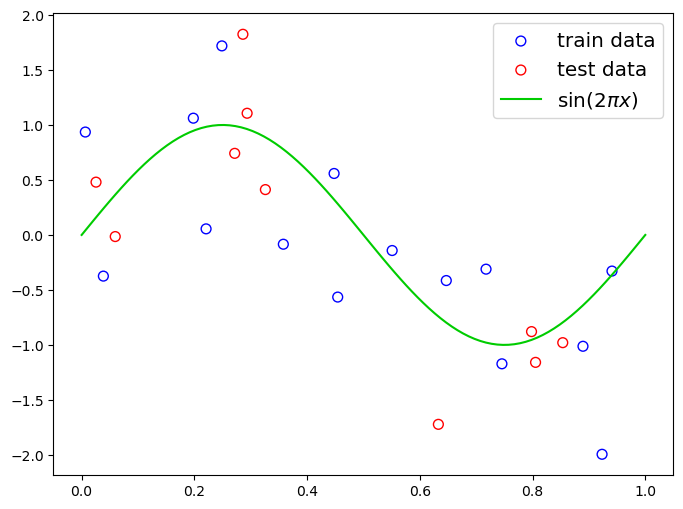

In [15]:
import numpy  # 不引用就会报错
# 生成数据
func = sin
interval = (0, 1)
train_num = 15
test_num = 10
noise = 0.5  # 0.1
X_train, y_train = create_toy_data(func=func, interval=interval, sample_num=train_num, noise=noise)
X_test, y_test = create_toy_data(func=func,interval=interval, sample_num=test_num, noise=noise)

X_underlying = paddle.linspace(interval[0], interval[1], num=100)
y_underlying = sin(X_underlying)

# 绘制图像
plt.rcParams["figure.figsize"] = (8.0, 6.0)
plt.scatter(X_train, y_train, facecolor="none", edgecolor="b", s=50, label="train data")
plt.scatter(X_test, y_test, facecolor="none", edgecolor="r", s=50, label="test data")
plt.plot(X_underlying.detach().numpy(), y_underlying.detach().numpy(), c="#00cc00", label=r"$\sin(2\pi x)$")
plt.legend(fontsize="x-large")
# plt.savefig("ml-vis2_noise05.pdf")
plt.show()

### 2.3.2 模型构建

In [16]:
# 多项式转换
def polynomial_basis_function(x, degree=2):
    """
    输入:
        - x: tensor, 输入的数据, shape=[N, 1]
        - degree: int, 多项式的阶数
        example Input: [[2], [3], [4]], degree=2
        example Output: [[2^1, 2^2], [3^1, 3^2], [4^1, 4^2]]
        注意: 本案例中，在degree>=1时不生成全为1的一列数据; degree为0时生成形状与输入形状相同，
              全1的Tensor
    输出:
        - x_result: tensor
    """

    if degree == 0:
        return paddle.ones(shape=x.shape, dtype="float32")

    x_tmp = x
    x_result = x_tmp

    for i in range(2, degree+1):
        x_tmp = paddle.multiply(x_tmp, x)  # 逐元素相乘
        x_result = paddle.concat((x_result, x_tmp), axis=-1)

    return x_result

# 简单测试
data = [[2], [3], [4]]
X = paddle.to_tensor(data=data, dtype="float32")
degree = 3
transformed_X = polynomial_basis_function(X, degree=degree)
print("转换前: ", X)
print("阶数为: ", degree, "转换后: ", transformed_X)

转换前:  Tensor(shape=[3, 1], dtype=float32, place=Place(cpu), stop_gradient=True,
       [[2.],
        [3.],
        [4.]])
阶数为:  3 转换后:  Tensor(shape=[3, 3], dtype=float32, place=Place(cpu), stop_gradient=True,
       [[2. , 4. , 8. ],
        [3. , 9. , 27.],
        [4. , 16., 64.]])


### 2.3.3 模型训练

{'w': Tensor(shape=[1], dtype=float32, place=Place(cpu), stop_gradient=True,
       [0.]), 'b': Tensor(shape=[], dtype=float32, place=Place(cpu), stop_gradient=True,
       -0.13784462)}
{'w': Tensor(shape=[1], dtype=float32, place=Place(cpu), stop_gradient=True,
       [-2.09566569]), 'b': Tensor(shape=[1], dtype=float32, place=Place(cpu), stop_gradient=True,
       [0.89425462])}
{'w': Tensor(shape=[5], dtype=float32, place=Place(cpu), stop_gradient=True,
       [ 6.60328007 , -33.20870590,  61.72695923, -62.08679199,  25.79716492]), 'b': Tensor(shape=[1], dtype=float32, place=Place(cpu), stop_gradient=True,
       [0.32846892])}
{'w': Tensor(shape=[12], dtype=float32, place=Place(cpu), stop_gradient=True,
       [-25.19866753  ,  106.31766510 , -116.31378174 ,  56.44543457  ,
        -1173.94873047,  2680.15917969,  554.46405029 , -4788.22705078,
         1873.52001953,  0.49761963   ,  2802.66113281, -1972.83166504]), 'b': Tensor(shape=[1], dtype=float32, place=Place(cpu), stop_gra

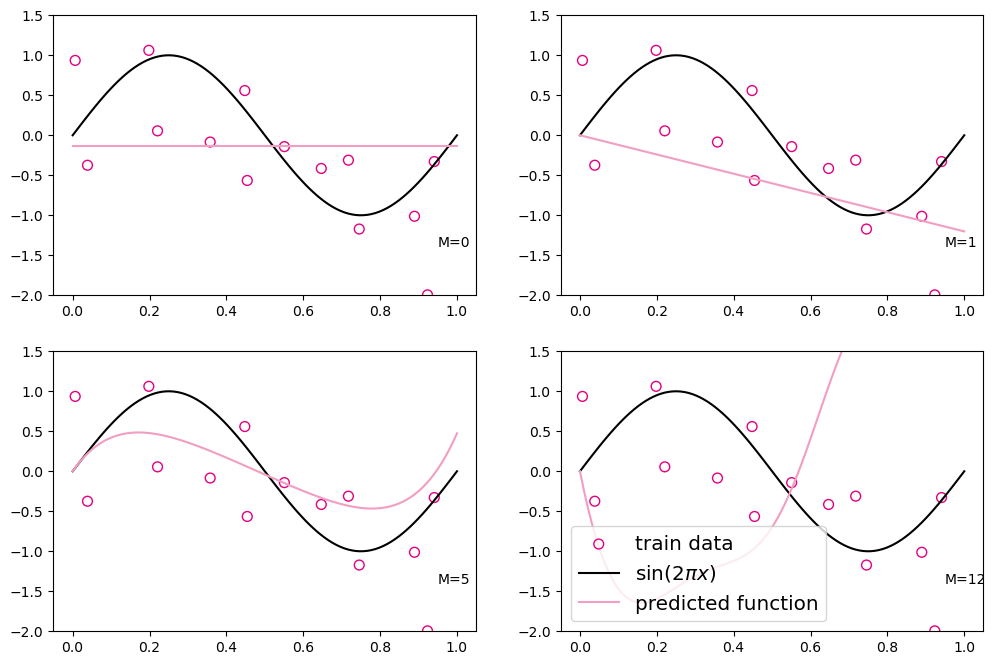

In [17]:
plt.rcParams["figure.figsize"] = (12.0, 8.0)

for i, degree in enumerate([0, 1, 5, 12]):  # []中为多项式的阶数
    model = Linear(degree)
    X_train_transformed = polynomial_basis_function(X_train.reshape([-1, 1]), degree)
    X_underlying_transformed = polynomial_basis_function(X_underlying.reshape([-1, 1]), degree)

    model = optimizer_lsm(model, X_train_transformed, y_train.reshape([-1, 1]))  # 拟合得到参数

    y_underlying_pred = model(X_underlying_transformed).squeeze()

    print(model.params)

    # 绘制图像
    plt.subplot(2, 2, i+1)
    plt.scatter(X_train, y_train, facecolor="none", edgecolor="#e4007f", s=50, label="train data")
    plt.plot(X_underlying.detach().numpy(), y_underlying.detach().numpy(), c="#000000", label=r"$\sin(2\pi x)$")
    plt.plot(X_underlying.detach().numpy(), y_underlying_pred.detach().numpy(), c="#f19ec2", label="predicted function")
    plt.ylim(-2, 1.5)
    plt.annotate("M={}".format(degree), xy=(0.95, -1.4))

#plt.legend(bbox_to_ancher=(1.05, 0.64), loc=2, borderaxespad=0.)
plt.legend(loc="lower left", fontsize="x-large")
# plt.savefig("ml-vis3.pdf")
plt.show()

### 2.3.4 模型评估

train errors: 
 [0.815338671207428, 0.6932471990585327, 0.540990948677063, 0.44016408920288086, 0.49950990080833435, 0.5763197541236877, 1.4335389137268066, 6.183426856994629, 2.6742608547210693]
test errors: 
 [1.1686657667160034, 0.9855191111564636, 0.8266595602035522, 0.4917382299900055, 0.5376600027084351, 0.5972442030906677, 2.7836642265319824, 4.721729755401611, 1.6373029947280884]
distribution errors: 
 [0.5140011310577393, 0.6000897288322449, 0.3483930230140686, 0.1127815917134285, 0.12548044323921204, 0.16176003217697144, 2.1908023357391357, 9.803287506103516, 4.41718864440918]


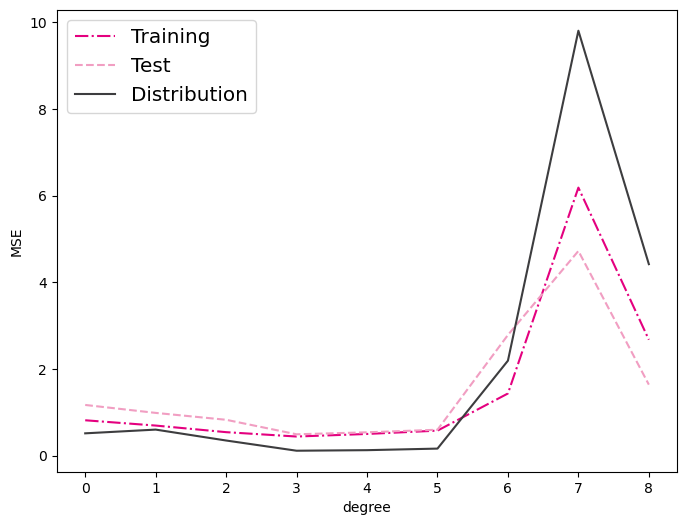

In [18]:
# 训练误差和测试误差
training_errors = []
test_errors = []
distribution_errors = []

# 遍历多项式阶数
for i in range(9):
    model = Linear(i)

    X_train_transformed = polynomial_basis_function(X_train.reshape([-1, 1]), i)
    X_test_transformed = polynomial_basis_function(X_test.reshape([-1, 1]), i)
    X_underlying_transformed = polynomial_basis_function(X_underlying.reshape([-1, 1]), i)

    optimizer_lsm(model, X_train_transformed, y_train.reshape([-1, 1]))

    y_train_pred = model(X_train_transformed).squeeze()
    y_test_pred = model(X_test_transformed).squeeze()
    y_underlying_pred = model(X_underlying_transformed).squeeze()
    
    train_mse = mean_squared_error(y_true=y_train, y_pred=y_train_pred).item()
    training_errors.append(train_mse)

    test_mse = mean_squared_error(y_true=y_test, y_pred=y_test_pred).item()
    test_errors.append(test_mse)

    distribution_mse = mean_squared_error(y_true=y_underlying, y_pred=y_underlying_pred).item()
    distribution_errors.append(distribution_mse)

print("train errors: \n", training_errors)
print("test errors: \n", test_errors)
print("distribution errors: \n", distribution_errors)

# 绘制图片
plt.rcParams["figure.figsize"] = (8.0, 6.0)
plt.plot(training_errors, "-.", mfc="none", mec="#e4007f", ms=10, c="#e4007f", label="Training")
plt.plot(test_errors, "--", mfc="none", mec="#f19ec2", ms=10, c="#f19ec2", label="Test")
plt.plot(distribution_errors, "-", mfc="none", mec="#3D3D3F", ms=10, c="#3D3D3F", label="Distribution")
plt.legend(fontsize="x-large")
plt.xlabel("degree")
plt.ylabel("MSE")
# plt.savefig("ml-mse-error.pdf")
plt.show()

<>:33: SyntaxWarning: invalid escape sequence '\e'
<>:33: SyntaxWarning: invalid escape sequence '\e'
C:\Users\WTQ13\AppData\Local\Temp\ipykernel_16900\2608951253.py:33: SyntaxWarning: invalid escape sequence '\e'
  plt.plot(X_underlying.detach().numpy(), y_underlying_pred_reg.detach().numpy(), c="#ffD700", linestyle="-.", label="$deg. =8, \ell_2 reg$")


mse: 1.6373029947280884
mse_with_12_reg:  0.7508951425552368


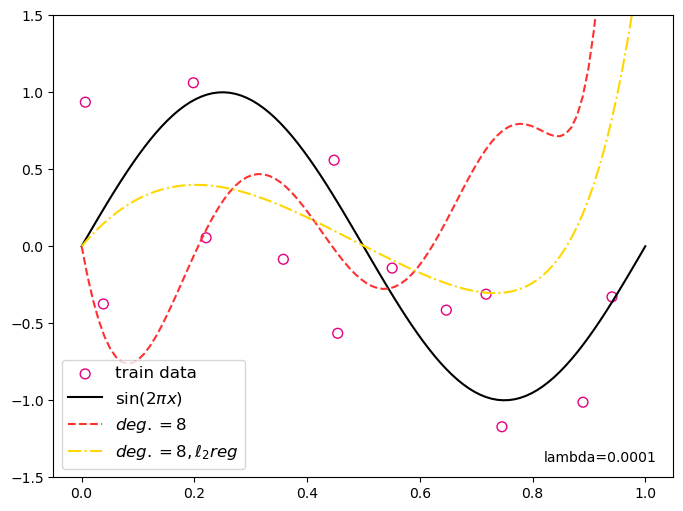

In [28]:
import numpy

degree = 8  # 多项式系数
reg_lambda = 0.0001  # 正则化系数

X_train_transformed = polynomial_basis_function(X_train.reshape([-1, 1]), degree)
X_test_transformed = polynomial_basis_function(X_test.reshape([-1, 1]), degree)
X_underlying_transformed = polynomial_basis_function(X_underlying.reshape([-1, 1]), degree)

model = Linear(degree)

optimizer_lsm(model, X_train_transformed, y_train.reshape([-1, 1]))

y_test_pred = model(X_test_transformed).squeeze()
y_underlying_pred = model(X_underlying_transformed).squeeze()

model_reg = Linear(degree)

optimizer_lsm(model_reg, X_train_transformed, y_train.reshape([-1, 1]), reg_lambda=reg_lambda)

y_test_pred_reg = model_reg(X_test_transformed).squeeze()
y_underlying_pred_reg = model_reg(X_underlying_transformed).squeeze()

mse = mean_squared_error(y_true=y_test, y_pred=y_test_pred).item()
print("mse:", mse)
mse_reg = mean_squared_error(y_true=y_test, y_pred=y_test_pred_reg).item()
print("mse_with_12_reg: ", mse_reg)

# 绘制图像
plt.scatter(X_train, y_train, facecolor="none", edgecolor="#e4007f", s=50, label="train data")
plt.plot(X_underlying.detach().numpy(), y_underlying.detach().numpy(), c="#000000", label=r"$\sin(2\pi x)$")
plt.plot(X_underlying.detach().numpy(), y_underlying_pred.detach().numpy(), c="#ff3030", linestyle="--", label="$deg. = 8$")
plt.plot(X_underlying.detach().numpy(), y_underlying_pred_reg.detach().numpy(), c="#ffD700", linestyle="-.", label="$deg. =8, \ell_2 reg$")
plt.ylim(-1.5, 1.5)
plt.annotate("lambda={}".format(reg_lambda), xy=(0.82, -1.4))
plt.legend(fontsize="large")
# plt.savefig("ml-cis4.pdf")
plt.show()